# Shortcut Learning Visualization with ResNet18 and Grad-CAM

This notebook visualizes "Shortcut Learning" using a pre-trained ResNet18 model on a sample from the Husky vs Wolf dataset. 
Shortcut learning occurs when a model relies on unintended features (like the background snow for a husky) instead of the actual subject.

We use Grad-CAM to show which parts of the image the model focuses on to make its prediction.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from functions.dataset import HuskyWolfDataset
from functions.train import train


# 1. Veri Setinin ve DataLoader'ların Hazırlanması
# test_dataset dosyası modelin yanlı (biased) öğrenimi için eğitim seti olarak kabul edilir.
# exchanged_background (arka planı değiştirilmiş) ise test seti olacaktır.
train_dir = "/home/furkan/Projects/ML_Algorithms/husky-wolf/archive/test_dataset"
test_dir = "/home/furkan/Projects/ML_Algorithms/husky-wolf/archive/exchanged_background"

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = HuskyWolfDataset(data_dir=train_dir, transform=transform_train)
test_dataset = HuskyWolfDataset(data_dir=test_dir, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. ResNet18 Modelinin Yüklenmesi ve Son Katmanın (Linear) Değiştirilmesi
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # 2 Sınıf: Husky ve Wolf
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)



# 3. Modelin Eğitimi (Kısa Eğitim - Örn: 3 Epoch)
num_epochs = 3

In [3]:
save_path = "best_husky_wolf_model.pth"

train_losses, train_accs, val_losses, val_accs = train(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,  # test_loader (exchanged_background) verisini val olarak veriyoruz
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    save_path=save_path,
    num_epochs=3,
    patience=2,
    log_path="shortcut_training.log"
)

[2026_02_25_21_20_32] Training started.
Epoch 1/3 - Validation: 100%|██████████| 6/6 [00:01<00:00,  3.37it/s]
[2026_02_25_21_20_35] Epoch [1/3]
[2026_02_25_21_20_35]   Train Loss: 0.7164, Train Acc: 0.5670
[2026_02_25_21_20_35]   Val   Loss: 1.8838, Val   Acc: 0.0455
[2026_02_25_21_20_35]   Best model saved with val_loss: 1.8838


Epoch [1/3]
  Train Loss: 0.7164, Train Acc: 0.5670
  Val   Loss: 1.8838, Val   Acc: 0.0455
  Best model saved with val_loss: 1.8838


Epoch 2/3 - Validation: 100%|██████████| 6/6 [00:01<00:00,  3.87it/s]
[2026_02_25_21_20_38] Epoch [2/3]
[2026_02_25_21_20_38]   Train Loss: 0.4272, Train Acc: 0.8247
[2026_02_25_21_20_38]   Val   Loss: 4.1597, Val   Acc: 0.0455
[2026_02_25_21_20_38]   No improvement. Early stopping counter: 1/2


Epoch [2/3]
  Train Loss: 0.4272, Train Acc: 0.8247
  Val   Loss: 4.1597, Val   Acc: 0.0455
  No improvement. Early stopping counter: 1/2


Epoch 3/3 - Validation: 100%|██████████| 6/6 [00:01<00:00,  3.28it/s]
[2026_02_25_21_20_41] Epoch [3/3]
[2026_02_25_21_20_41]   Train Loss: 0.3418, Train Acc: 0.8660
[2026_02_25_21_20_41]   Val   Loss: 4.9693, Val   Acc: 0.0000
[2026_02_25_21_20_41]   No improvement. Early stopping counter: 2/2
[2026_02_25_21_20_41]   Early stopping triggered. Training stopped.
[2026_02_25_21_20_41] 
========== BEST MODEL SUMMARY ==========
[2026_02_25_21_20_41] Best Epoch      : 1
[2026_02_25_21_20_41] Val Loss        : 1.8838
[2026_02_25_21_20_41] ========================================


Epoch [3/3]
  Train Loss: 0.3418, Train Acc: 0.8660
  Val   Loss: 4.9693, Val   Acc: 0.0000
  No improvement. Early stopping counter: 2/2
  Early stopping triggered. Training stopped.

========== BEST MODEL SUMMARY ==========
Best Epoch      : 1
Val Loss        : 1.8838


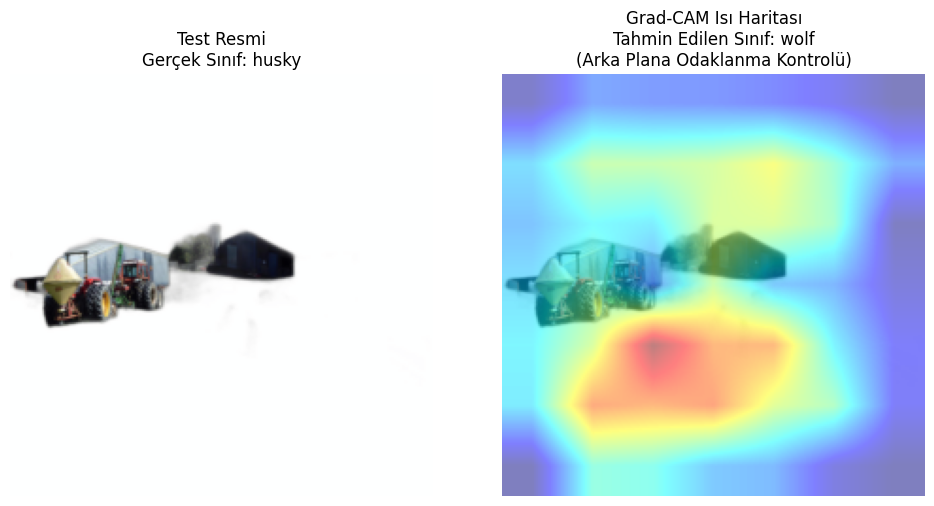

In [4]:

# 4. Exchanged Background Veri Setinde Test ve Grad-CAM ile Kısayol Öğreniminin Doğrulanması
model.eval()

# Test setinden (arka planı değiştirilmiş) bir resim seçiyoruz
test_img_tensor, test_label = test_dataset[0] # Husky veya Wolf
input_tensor = test_img_tensor.unsqueeze(0).to(device)

# Görselleştirme için resmi De-normalize ediyoruz
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
visual_img = test_img_tensor.numpy().transpose((1, 2, 0))
visual_img = std * visual_img + mean
visual_img = np.clip(visual_img, 0, 1)

# Grad-CAM için hedef katman olarak ResNet18'in son evrişimsel katmanını (layer4[-1]) belirliyoruz
# Burada nn.Linear (fc) yerine Conv katmanını hedeflediğimize dikkat edelim.
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Grad-CAM haritasını oluştur
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0, :]

# Orijinal resmin üzerine ısı haritasını uygula
cam_image = show_cam_on_image(visual_img, grayscale_cam, use_rgb=True)

# Test resminin sınıf durumları
class_names = train_dataset.classes
true_class = class_names[test_label]

with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    pred_class = class_names[predicted.item()]

# Çıktılar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(visual_img)
axes[0].set_title(f'Test Resmi\nGerçek Sınıf: {true_class}')
axes[0].axis('off')

axes[1].imshow(cam_image)
axes[1].set_title(f'Grad-CAM Isı Haritası\nTahmin Edilen Sınıf: {pred_class}\n(Arka Plana Odaklanma Kontrolü)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

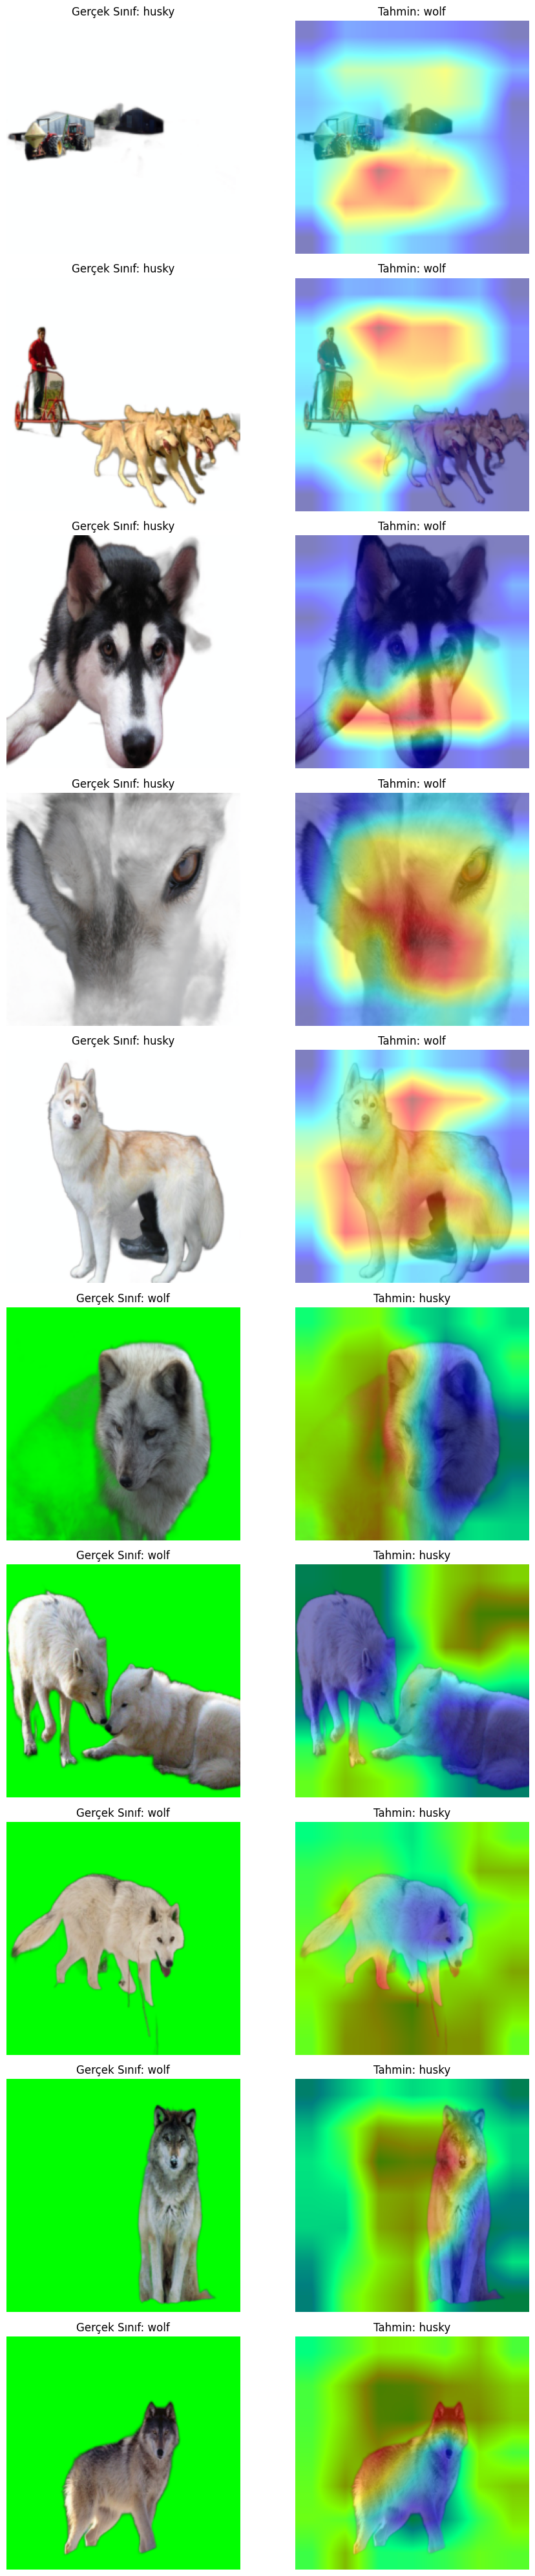

In [5]:
# 5 Husky ve 5 Wolf için Kısayol Öğrenimi (Grad-CAM) Gösterimi
import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()

# İlk 5 Husky (label=0) ve ilk 5 Wolf (label=1) index'lerini buluyoruz
husky_indices = [i for i, label in enumerate(test_dataset.labels) if label == 0][:5]
wolf_indices = [i for i, label in enumerate(test_dataset.labels) if label == 1][:5]
selected_indices = husky_indices + wolf_indices

# Hedef katman (ResNet18 için son evrişimsel katman)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

class_names = train_dataset.classes

fig, axes = plt.subplots(10, 2, figsize=(10, 40))

for i, idx in enumerate(selected_indices):
    test_img_tensor, test_label = test_dataset[idx]
    input_tensor = test_img_tensor.unsqueeze(0).to(device)
    
    # De-normalize işlemi
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    visual_img = test_img_tensor.numpy().transpose((1, 2, 0))
    visual_img = std * visual_img + mean
    visual_img = np.clip(visual_img, 0, 1)
    
    # Grad-CAM maskesi
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]
    
    # Orijinal resim üzerine bindir
    cam_image = show_cam_on_image(visual_img, grayscale_cam, use_rgb=True)
    
    true_class = class_names[test_label]
    
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        pred_class = class_names[predicted.item()]
        
    axes[i, 0].imshow(visual_img)
    axes[i, 0].set_title(f'Gerçek Sınıf: {true_class}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title(f'Tahmin: {pred_class}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


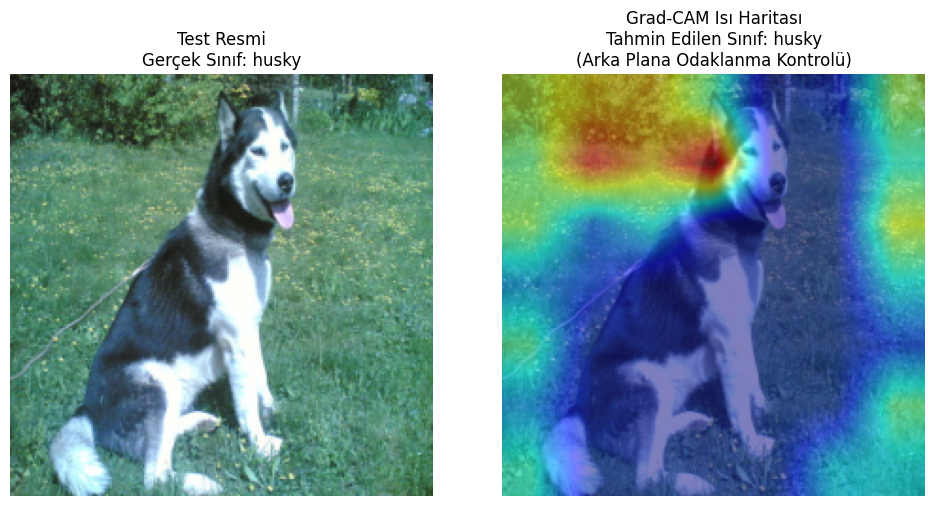

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import os

# Özel Olarak Belirtilen resim üzerinde Test: husky2.jpg
model.eval()

img_path = "/home/furkan/Projects/ML_Algorithms/husky-wolf/archive/test_dataset/husky/husky2.jpg"
if not os.path.exists(img_path):
    print(f"Bulunamadı: {img_path}")
else:
    # Resmi yükleme ve dönüştürme
    image = Image.open(img_path).convert("RGB")
    
    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = transform_test(image).unsqueeze(0).to(device)
    
    # Görselleştirme için resmi De-normalize ediyoruz
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    visual_img = transform_test(image).numpy().transpose((1, 2, 0))
    visual_img = std * visual_img + mean
    visual_img = np.clip(visual_img, 0, 1)
    
    # Grad-CAM için hedef katman olarak ResNet18'in son evrişimsel katmanını (layer4[-1]) belirliyoruz
    # Eğer model_v2 varsa o kullanılır, değilse önceki model
    try:
        target_model = model_v2
    except NameError:
        target_model = model
        
    target_layers = [target_model.layer4[-1]]
    cam = GradCAM(model=target_model, target_layers=target_layers)
    
    # Grad-CAM haritasını oluştur
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]
    
    # Orijinal resmin üzerine ısı haritasını uygula
    cam_image = show_cam_on_image(visual_img, grayscale_cam, use_rgb=True)
    
    # Test resminin sınıf durumları
    true_class = "husky"
    class_names = ["husky", "wolf"]
    
    with torch.no_grad():
        outputs = target_model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        pred_class = class_names[predicted.item()]
    
    # Çıktılar
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(visual_img)
    axes[0].set_title(f'Test Resmi\nGerçek Sınıf: {true_class}')
    axes[0].axis('off')
    
    axes[1].imshow(cam_image)
    axes[1].set_title(f'Grad-CAM Isı Haritası\nTahmin Edilen Sınıf: {pred_class}\n(Arka Plana Odaklanma Kontrolü)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
